In [1]:
# CELL 0 — Install required libraries
import subprocess
import sys

required_packages = [
    "pandas",
    "numpy",
    "spacy",
    "networkx",
    "matplotlib",
    "scipy",
    "scikit-learn",
    "kaggle",
]

print("Installing required packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *required_packages])

# Ensure spaCy English model is available
try:
    import spacy
    spacy.load("en_core_web_sm")
    print("spaCy model already installed: en_core_web_sm")
except Exception:
    subprocess.check_call([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    print("spaCy model installed: en_core_web_sm")

print("All required libraries are installed.")

Installing required packages...
spaCy model already installed: en_core_web_sm
All required libraries are installed.


Cell 1 — Install & download dependencies


In [2]:
# ============================================================
#  CELL 1 — Install & Download Dependencies  (LOCAL VERSION)
#
#  Make sure your ml_env virtual environment is ACTIVATED
#  before running this notebook:
#    source ml_env/bin/activate
#
#  This cell installs spaCy and all required packages.
#  It is safe to re-run — pip skips already-installed packages.
# ============================================================

import subprocess, sys

packages = ['spacy', 'networkx', 'scipy', 'pandas',
            'numpy', 'scikit-learn', 'matplotlib', 'kaggle']

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'],
                   check=True)

# Download spaCy English model (skips if already installed)
try:
    import spacy
    spacy.load('en_core_web_sm')
    print('   spaCy model already installed — skipping download')
except OSError:
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'],
                   check=True)

print('\n✅ All dependencies ready!')

   spaCy model already installed — skipping download

✅ All dependencies ready!


Cell 2 — Import all libraries


In [3]:
# ============================================================
#  CELL 2 — Import All Libraries
#  We import every library we need before starting the project.
# ============================================================

import pandas as pd
import numpy as np
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
from scipy.sparse import hstack, csr_matrix

# Load spaCy's English NLP model
nlp = spacy.load('en_core_web_sm')

print('✅ All libraries imported successfully!')
print(f'   spaCy version     : {spacy.__version__}')
print(f'   networkx version  : {nx.__version__}')

# ── Locate project root (works wherever Jupyter is launched from) ──────────
import pathlib as _pl

def _find_project_root():
    """Walk up from CWD until we find the dir that has both backend/ and training/."""
    d = _pl.Path.cwd().resolve()
    for _ in range(8):
        if (d / 'backend').is_dir() and (d / 'training').is_dir():
            return d
        d = d.parent
    # Last-resort: notebook lives at training/notebooks/ so go up 2 levels
    return _pl.Path.cwd().resolve().parent.parent

PROJECT_ROOT = _find_project_root()
print(f'   Project root : {PROJECT_ROOT}')


✅ All libraries imported successfully!
   spaCy version     : 3.8.14
   networkx version  : 3.6.1
   Project root : /home/developer-akshat/Kanika/Fake_New_Detection


### Download Dataset via Kaggle API

**One-time setup (do this in your terminal, not here):**

1. Go to https://www.kaggle.com/me/account → API section → **Create New API Token**
2. This downloads `kaggle.json` to your Downloads folder
3. Run these commands in your terminal:

```bash
mkdir -p ~/.kaggle
cp ~/Downloads/kaggle.json ~/.kaggle/
chmod 600 ~/.kaggle/kaggle.json
```

Then come back and run Cell 3 below.


In [4]:
# ============================================================
#  CELL 3 — Download Dataset from Kaggle  (LOCAL VERSION)
#
#  Downloads Fake.csv and True.csv into the PROJECT ROOT
#  (the folder that contains backend/ and training/).
#
#  One-time setup — do this in your terminal first:
#    mkdir -p ~/.kaggle
#    cp ~/Downloads/kaggle.json ~/.kaggle/
#    chmod 600 ~/.kaggle/kaggle.json   # Linux/Mac only
# ============================================================

import os, zipfile

# ── Check kaggle.json exists ───────────────────────────────
kaggle_cred = os.path.expanduser('~/.kaggle/kaggle.json')
if not os.path.exists(kaggle_cred):
    raise FileNotFoundError(
        '❌ ~/.kaggle/kaggle.json not found!\n'
        '   Follow the setup instructions in the markdown cell above first.'
    )
print('✅ kaggle.json found')

fake_csv = PROJECT_ROOT / 'Fake.csv'
true_csv = PROJECT_ROOT / 'True.csv'

if fake_csv.exists() and true_csv.exists():
    print('   Fake.csv and True.csv already exist — skipping download')
else:
    print('⏳ Downloading dataset from Kaggle...')
    orig_dir = os.getcwd()
    os.chdir(PROJECT_ROOT)          # download into project root
    os.system('kaggle datasets download clmentbisaillon/fake-and-real-news-dataset --quiet')

    zip_path = PROJECT_ROOT / 'fake-and-real-news-dataset.zip'
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(PROJECT_ROOT)
        zip_path.unlink()
        print('✅ Dataset extracted!')
    else:
        raise FileNotFoundError('❌ Download failed — check your kaggle.json credentials.')
    os.chdir(orig_dir)

# ── Load CSVs ─────────────────────────────────────────────
fake_df = pd.read_csv(fake_csv)
true_df = pd.read_csv(true_csv)

print('\n📂 Dataset loaded!')
print(f'\n   Fake news articles : {len(fake_df):,}')
print(f'   Real news articles : {len(true_df):,}')
print(f'\n   Fake.csv columns   : {list(fake_df.columns)}')
print(f'   True.csv columns   : {list(true_df.columns)}')


✅ kaggle.json found
   Fake.csv and True.csv already exist — skipping download

📂 Dataset loaded!

   Fake news articles : 23,481
   Real news articles : 21,417

   Fake.csv columns   : ['title', 'text', 'subject', 'date']
   True.csv columns   : ['title', 'text', 'subject', 'date']


Cell 4 — Clean and prepare the data


✅ Data prepared successfully!

   Total articles     : 44,898
   Fake articles      : 23,481
   Real articles      : 21,417
   Missing values     : 0


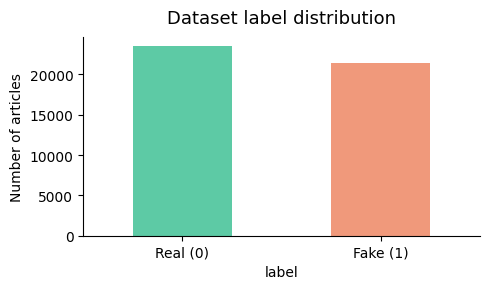

In [5]:
# ============================================================
#  CELL 4 — Clean & Prepare the Data
#
#  We:
#  - Add a 'label' column  (1 = Fake,  0 = Real)
#  - Merge both datasets into one dataframe
#  - Drop any rows with missing values
#  - Combine the title + article text into one 'content' column
#  - Shuffle the data so fake and real rows are mixed
# ============================================================

# Step 4a: Label the data
fake_df['label'] = 1   # 1 means FAKE
true_df['label'] = 0   # 0 means REAL

# Step 4b: Merge into one dataframe
df = pd.concat([fake_df, true_df], ignore_index=True)

# Step 4c: Drop rows with any missing values
df.dropna(inplace=True)

# Step 4d: Combine title and article text for richer features
df['content'] = df['title'] + ' ' + df['text']

# Step 4e: Shuffle the dataset (random_state=42 ensures reproducibility)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Step 4f: Show a summary
print('✅ Data prepared successfully!')
print(f'\n   Total articles     : {len(df):,}')
print(f'   Fake articles      : {df["label"].value_counts()[1]:,}')
print(f'   Real articles      : {df["label"].value_counts()[0]:,}')
print(f'   Missing values     : {df.isnull().sum().sum()}')

# Show the label distribution as a bar chart
fig, ax = plt.subplots(figsize=(5, 3))
colors = ['#5DCAA5', '#F0997B']
df['label'].value_counts().plot(kind='bar', color=colors, ax=ax, edgecolor='none')
ax.set_title('Dataset label distribution', fontsize=13, pad=10)
ax.set_xticklabels(['Real (0)', 'Fake (1)'], rotation=0)
ax.set_ylabel('Number of articles')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

Cell 5 — Split data and build the TF-IDF text baseline


In [6]:
# ============================================================
#  CELL 5 — Split Data & Build Text-Only Baseline (PAC)
#
#  This is PHASE 1 of our model:
#  - Split data: 80% training, 20% testing
#  - Convert text to numbers using TF-IDF
#  - Train a Passive Aggressive Classifier on text alone
#  - Record the baseline accuracy (we'll beat this later!)
#
#  PASSIVE AGGRESSIVE CLASSIFIER explained:
#  - "Passive"   → if the prediction is correct, do nothing
#  - "Aggressive"→ if the prediction is wrong, update strongly
#  It is extremely fast and works very well for text tasks.
# ============================================================

X = df['content']   # Input features: the article text
y = df['label']     # Target: 0 (real) or 1 (fake)

# Step 5a: Train/Test split — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 5b: TF-IDF Vectorization
# - stop_words='english' removes common words like "the", "is", "and"
# - max_df=0.7 ignores words appearing in more than 70% of articles
# - max_features=50000 keeps only the top 50,000 most useful words
tfidf = TfidfVectorizer(
    stop_words='english',
    max_df=0.7,
    max_features=50000
)

X_train_tfidf = tfidf.fit_transform(X_train)   # Fit + transform training data
X_test_tfidf  = tfidf.transform(X_test)        # Only transform test data!

# Step 5c: Train the baseline Passive Aggressive Classifier
pac_text = PassiveAggressiveClassifier(max_iter=50, random_state=42)
pac_text.fit(X_train_tfidf, y_train)

# Step 5d: Evaluate
y_pred_text = pac_text.predict(X_test_tfidf)
acc_text = accuracy_score(y_test, y_pred_text)

print('✅ Text-only model trained!')
print(f'\n   Training samples   : {X_train_tfidf.shape[0]:,}')
print(f'   Test samples       : {X_test_tfidf.shape[0]:,}')
print(f'   Vocabulary size    : {X_train_tfidf.shape[1]:,} words')
print(f'\n   ── Baseline Accuracy (Text only) ──')
print(f'   {round(acc_text * 100, 2)}%')
print(f'\n   Classification Report:')
print(classification_report(y_test, y_pred_text,
                             target_names=['Real', 'Fake']))

✅ Text-only model trained!

   Training samples   : 35,918
   Test samples       : 8,980
   Vocabulary size    : 50,000 words

   ── Baseline Accuracy (Text only) ──
   99.48%

   Classification Report:
              precision    recall  f1-score   support

        Real       0.99      1.00      0.99      4284
        Fake       1.00      0.99      0.99      4696

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Cell 6 — Named Entity Recognition (NER) with spaCy


In [7]:
# ============================================================
#  CELL 6 — Named Entity Recognition (NER) using spaCy
#                                         (LOCAL VERSION)
#
#  Uses nlp.pipe() with n_process=4 to run NER in parallel
#  across your CPU cores — much faster than a simple loop.
#
#  For every article, spaCy identifies named entities:
#    PERSON  → "Joe Biden", "Elon Musk"
#    ORG     → "NASA", "WHO", "CNN"
#    GPE     → Countries, cities — "India", "New York"
#    DATE    → "January 2023", "last Tuesday"
#    EVENT   → "World War II", "Olympics"
# ============================================================

import multiprocessing

ENTITY_TYPES = {'PERSON', 'ORG', 'GPE', 'DATE', 'EVENT'}
N_CORES = max(1, multiprocessing.cpu_count() - 1)  # leave 1 core free

def extract_entities_from_doc(doc):
    """Extract clean entities from an already-processed spaCy doc."""
    entities = []
    for ent in doc.ents:
        if ent.label_ in ENTITY_TYPES:
            clean = ent.text.lower().strip()
            if len(clean) > 2:
                entities.append(clean)
    return list(set(entities))

print(f'⏳ Extracting entities using {N_CORES} CPU cores...')
print(f'   (This may take 3–6 minutes depending on your machine)\n')

# Truncate text to first 3000 chars for speed, then batch-process
texts = df['content'].fillna('').str[:3000].tolist()

docs = nlp.pipe(texts, n_process=N_CORES, batch_size=64,
                disable=['parser', 'lemmatizer'])

df['entities'] = [extract_entities_from_doc(doc) for doc in docs]

# Summary
entity_counts = df['entities'].apply(len)
print('✅ Entity extraction complete!')
print(f'\n   Avg entities per article  : {entity_counts.mean():.1f}')
print(f'   Max entities in 1 article : {entity_counts.max()}')
print(f'   Articles with 0 entities  : {(entity_counts == 0).sum()}')

print('\n--- Sample: Fake article entities ---')
sample_fake = df[df['label']==1].iloc[0]
print(f'   Title    : {sample_fake["title"][:80]}...')
print(f'   Entities : {sample_fake["entities"][:8]}')

print('\n--- Sample: Real article entities ---')
sample_real = df[df['label']==0].iloc[0]
print(f'   Title    : {sample_real["title"][:80]}...')
print(f'   Entities : {sample_real["entities"][:8]}')

⏳ Extracting entities using 15 CPU cores...
   (This may take 3–6 minutes depending on your machine)

✅ Entity extraction complete!

   Avg entities per article  : 19.3
   Max entities in 1 article : 94
   Articles with 0 entities  : 185

--- Sample: Fake article entities ---
   Title    : Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Con...
   Entities : ['ben stein', 'jeanine pirro', 'ben stein calls', '21st century', 'pepperdine university', '9th circuit court', 'hollywood', 'the 9th circuit court']

--- Sample: Real article entities ---
   Title    : Trump drops Steve Bannon from National Security Council...
   Entities : ['fox news', 'november', 'susan rice', 'white house', 'donald trump', 'trump’s white house', 'breitbart news', 'syria']


Cell 7 — Build the Knowledge Graph


In [8]:
# ============================================================
#  CELL 7 — Build the Knowledge Graph
#
#  We now construct a graph (network) where:
#    NODES  = unique entities (e.g. "donald trump", "russia")
#    EDGES  = two entities appeared in the SAME article
#             (edge weight = how many times they co-occurred)
#
#  Each node also stores how many times it appeared in
#  fake news vs real news — this becomes a powerful feature!
# ============================================================

print('⏳ Building knowledge graph...')

G = nx.Graph()

for idx, row in df.iterrows():
    entities = row['entities']
    label    = row['label']

    # --- Add nodes ---
    for entity in entities:
        if not G.has_node(entity):
            G.add_node(entity, fake_count=0, real_count=0)

        # Increment fake/real counter for this entity
        if label == 1:
            G.nodes[entity]['fake_count'] += 1
        else:
            G.nodes[entity]['real_count'] += 1

    # --- Add edges (co-occurrence) ---
    for i in range(len(entities)):
        for j in range(i + 1, len(entities)):
            e1, e2 = entities[i], entities[j]
            if G.has_edge(e1, e2):
                G[e1][e2]['weight'] += 1
            else:
                G.add_edge(e1, e2, weight=1)

print('✅ Knowledge graph built!')
print(f'\n   Unique entities (nodes) : {G.number_of_nodes():,}')
print(f'   Co-occurrences (edges)  : {G.number_of_edges():,}')

# Show the top 10 most connected entities
degree_dict = dict(G.degree())
top_entities = sorted(degree_dict, key=degree_dict.get, reverse=True)[:10]

print(f'\n   Top 10 most connected entities:')
for i, ent in enumerate(top_entities, 1):
    fc = G.nodes[ent]['fake_count']
    rc = G.nodes[ent]['real_count']
    print(f'   {i:2}. {ent:<25} connections={degree_dict[ent]}  '
          f'fake={fc}  real={rc}')

⏳ Building knowledge graph...
✅ Knowledge graph built!

   Unique entities (nodes) : 127,994
   Co-occurrences (edges)  : 4,299,650

   Top 10 most connected entities:
    1. reuters                   connections=60366  fake=235  real=21337
    2. trump                     connections=59339  fake=10749  real=7616
    3. donald trump              connections=53740  fake=7954  real=8328
    4. u.s.                      connections=46513  fake=2918  real=11476
    5. the united states         connections=33615  fake=3211  real=5437
    6. tuesday                   connections=30164  fake=1710  real=5308
    7. wednesday                 connections=28376  fake=1461  real=5247
    8. washington                connections=28304  fake=1462  real=7493
    9. thursday                  connections=27596  fake=1486  real=5040
   10. obama                     connections=27469  fake=4648  real=1906


Cell 8 — Visualise the Knowledge Graph


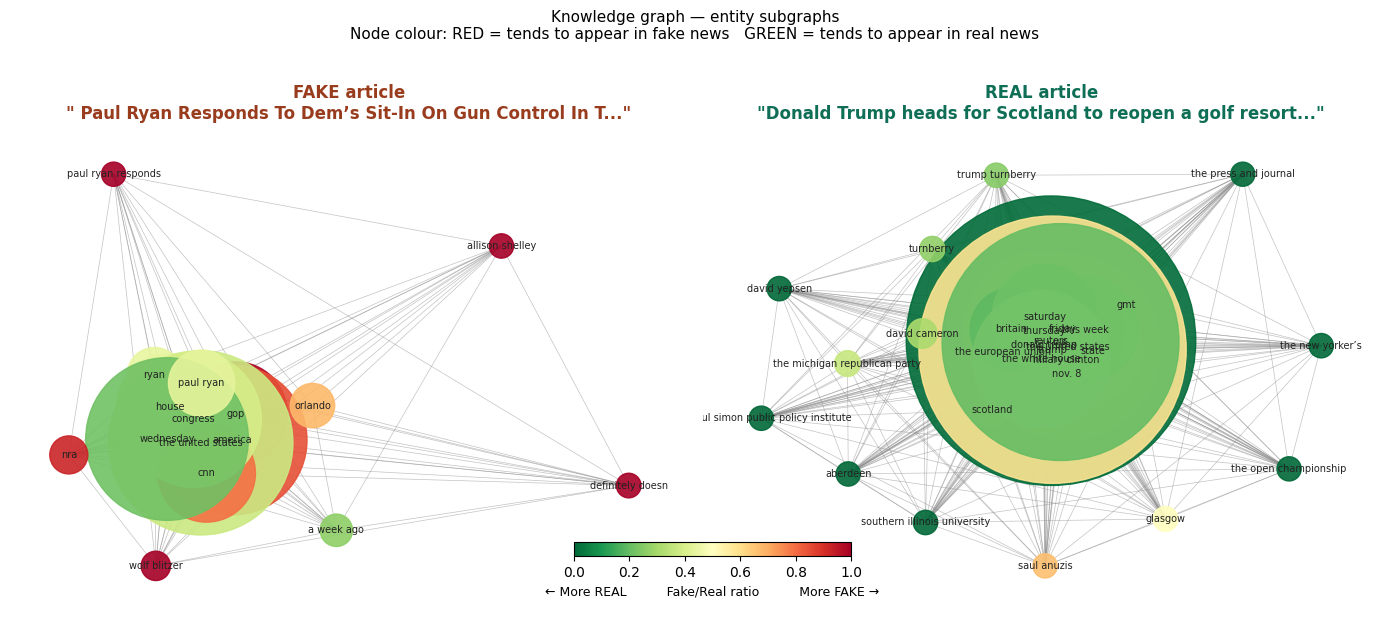

✅ Graph visualisation saved as 'entity_graph_comparison.png'


In [9]:
# ============================================================
#  CELL 8 — Visualise the Knowledge Graph
#
#  We draw two graphs side by side:
#    LEFT  → entity subgraph of a FAKE news article
#    RIGHT → entity subgraph of a REAL news article
#
#  Node color shows the entity's fake/real tendency:
#    RED   → entity mostly appears in fake news
#    GREEN → entity mostly appears in real news
# ============================================================

def draw_entity_graph(ax, entities, G, title, label_color):
    """Draws the entity subgraph of a single article."""
    valid = [e for e in entities if G.has_node(e)]

    if len(valid) < 2:
        ax.text(0.5, 0.5, 'Not enough entities\nto draw graph',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=11, color='gray')
        ax.set_title(title, fontsize=12, color=label_color, pad=10)
        ax.axis('off')
        return

    subgraph = G.subgraph(valid)
    pos = nx.spring_layout(subgraph, seed=42, k=1.5)

    # Calculate node color based on fake_ratio
    node_colors = []
    node_sizes  = []
    for node in subgraph.nodes():
        fc = G.nodes[node]['fake_count']
        rc = G.nodes[node]['real_count']
        ratio = fc / max(1, fc + rc)
        node_colors.append(ratio)
        total = fc + rc
        node_sizes.append(300 + total * 2)

    edge_weights = [subgraph[u][v].get('weight', 1) for u, v in subgraph.edges()]
    max_w = max(edge_weights) if edge_weights else 1
    edge_widths = [0.5 + 2.5 * (w / max_w) for w in edge_weights]

    nx.draw_networkx_nodes(subgraph, pos, ax=ax,
                           node_color=node_colors,
                           node_size=node_sizes,
                           cmap=plt.cm.RdYlGn_r,
                           vmin=0, vmax=1, alpha=0.9)
    nx.draw_networkx_edges(subgraph, pos, ax=ax,
                           width=edge_widths,
                           edge_color='#888888', alpha=0.5)
    nx.draw_networkx_labels(subgraph, pos, ax=ax,
                            font_size=7, font_color='#222222')
    ax.set_title(title, fontsize=12, color=label_color,
                 pad=10, fontweight='bold')
    ax.axis('off')


fake_samples = df[(df['label']==1) & (df['entities'].apply(len) >= 5)]
real_samples = df[(df['label']==0) & (df['entities'].apply(len) >= 5)]

fake_row = fake_samples.iloc[2]
real_row = real_samples.iloc[2]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Knowledge graph — entity subgraphs\n'
             'Node colour: RED = tends to appear in fake news   '
             'GREEN = tends to appear in real news',
             fontsize=11, y=1.02)

draw_entity_graph(axes[0], fake_row['entities'], G,
                  f'FAKE article\n"{fake_row["title"][:55]}..."',
                  label_color='#993C1D')

draw_entity_graph(axes[1], real_row['entities'], G,
                  f'REAL article\n"{real_row["title"][:55]}..."',
                  label_color='#0F6E56')

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal',
                    fraction=0.03, pad=0.08, shrink=0.5)
cbar.set_label('← More REAL          Fake/Real ratio          More FAKE →',
               fontsize=9)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'assets' / 'entity_graph_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Graph visualisation saved as 'entity_graph_comparison.png'")

Cell 9 — Extract Graph Features per Article


In [10]:
# CELL 9 — Faster graph feature extraction (low-overhead, no process IPC)

import time
import numpy as np
import pandas as pd

# Reuse caches if already present; otherwise build once
if 'node_counts' not in globals() or 'adjacency' not in globals():
    print('⏳ Building graph caches...')
    node_counts = {n: (d['fake_count'], d['real_count']) for n, d in G.nodes(data=True)}
    adjacency = {n: set(G.neighbors(n)) for n in G.nodes()}

print(f"✅ Cache ready: {len(node_counts):,} nodes")

def get_graph_features_fast(entities):
    if not entities:
        return [0, 0, 0.0, 0.0, 0.5]

    # Deduplicate per article (safe + faster)
    valid = [e for e in set(entities) if e in node_counts]
    n = len(valid)
    if n == 0:
        return [0, 0, 0.0, 0.0, 0.5]

    valid_set = set(valid)

    deg_sum = 0
    ratio_sum = 0.0

    for e in valid:
        # degree inside article subgraph
        deg_sum += len(adjacency[e] & valid_set)

        # fake ratio contribution
        fc, rc = node_counts[e]
        denom = fc + rc
        ratio_sum += (fc / denom) if denom else 0.5

    num_edges = deg_sum // 2
    avg_degree = deg_sum / n
    max_edges = n * (n - 1) / 2
    density = (num_edges / max_edges) if max_edges > 0 else 0.0
    fake_ratio = ratio_sum / n

    return [n, num_edges, avg_degree, density, fake_ratio]

# Alias so downstream cells can call either name
get_graph_features = get_graph_features_fast

print('⏳ Extracting graph features (fast path)...')
t0 = time.time()

graph_feat_list = [get_graph_features_fast(ents) for ents in df['entities'].tolist()]

elapsed = time.time() - t0
print(f"✅ Done in {elapsed:.1f} seconds")

graph_features_df = pd.DataFrame(
    graph_feat_list,
    columns=['num_entities', 'num_edges', 'avg_degree', 'density', 'fake_ratio']
)

print('\nFeature statistics:')
print(graph_features_df.describe().round(3))

⏳ Building graph caches...
✅ Cache ready: 127,994 nodes
⏳ Extracting graph features (fast path)...
✅ Done in 2.0 seconds

Feature statistics:
       num_entities  num_edges  avg_degree    density  fake_ratio
count     44898.000  44898.000   44898.000  44898.000   44898.000
mean         19.341    219.336      18.345      0.985       0.498
std           9.161    200.457       9.153      0.121       0.272
min           0.000      0.000       0.000      0.000       0.007
25%          13.000     78.000      12.000      1.000       0.233
50%          19.000    171.000      18.000      1.000       0.530
75%          26.000    325.000      25.000      1.000       0.745
max          94.000   4371.000      93.000      1.000       1.000


Cell 10 — Feature Fusion & Graph-Enhanced PAC


In [11]:
# ============================================================
#  CELL 10 — Feature Fusion & Graph-Enhanced PAC
#
#  We now COMBINE:
#    - TF-IDF features  (50,000 text-based columns)
#    - Graph features   (5 graph-based columns)
#  into one big feature matrix using scipy's hstack.
#
#  Then we train a SECOND Passive Aggressive Classifier
#  on this richer combined feature set.
#  The goal: beat the baseline accuracy from Cell 5.
# ============================================================

train_idx = y_train.index
test_idx  = y_test.index

graph_train = csr_matrix(graph_features_df.loc[train_idx].values)
graph_test  = csr_matrix(graph_features_df.loc[test_idx].values)

X_train_combined = hstack([X_train_tfidf, graph_train])
X_test_combined  = hstack([X_test_tfidf,  graph_test])

print(f'   Text-only feature shape      : {X_train_tfidf.shape}')
print(f'   Combined feature shape       : {X_train_combined.shape}')
print(f'   (Added {graph_train.shape[1]} graph feature columns)\n')

pac_graph = PassiveAggressiveClassifier(max_iter=50, random_state=42)
pac_graph.fit(X_train_combined, y_train)

y_pred_graph = pac_graph.predict(X_test_combined)
acc_graph    = accuracy_score(y_test, y_pred_graph)

print('✅ Graph-enhanced model trained!')
print(f'\n   ── Graph-enhanced Accuracy ──')
print(f'   {round(acc_graph * 100, 2)}%')
print(f'\n   Classification Report:')
print(classification_report(y_test, y_pred_graph,
                             target_names=['Real', 'Fake']))

   Text-only feature shape      : (35918, 50000)
   Combined feature shape       : (35918, 50005)
   (Added 5 graph feature columns)

✅ Graph-enhanced model trained!

   ── Graph-enhanced Accuracy ──
   95.91%

   Classification Report:
              precision    recall  f1-score   support

        Real       0.99      0.92      0.96      4284
        Fake       0.93      0.99      0.96      4696

    accuracy                           0.96      8980
   macro avg       0.96      0.96      0.96      8980
weighted avg       0.96      0.96      0.96      8980



Cell 11 — Compare Both Models


        MODEL COMPARISON RESULTS
  Text-only PAC accuracy    :   99.48%
  Graph-enhanced PAC acc.   :   95.91%
  Improvement               :   -3.56%


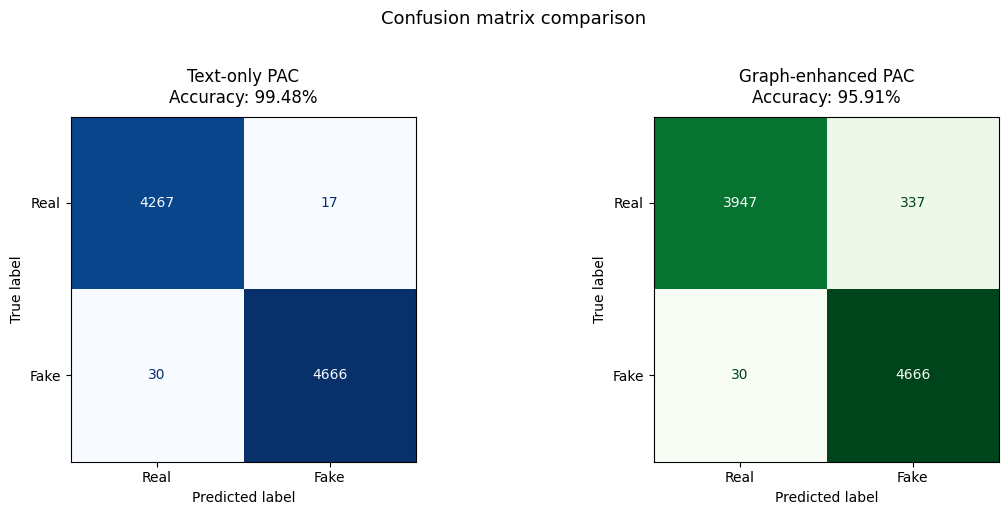

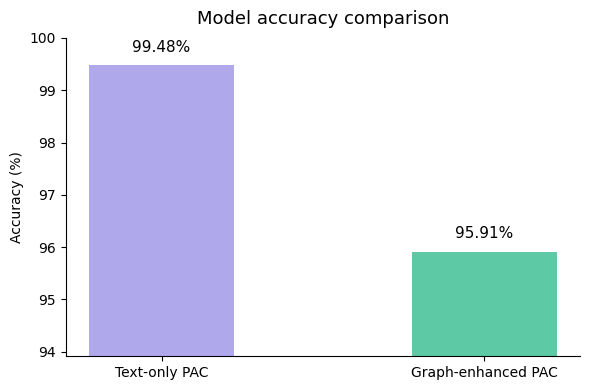

✅ Visualisations saved to assets/ and frontend/public/images/


In [12]:
# ============================================================
#  CELL 11 — Compare Both Models
#
#  We compare:
#    Model A → Text-only PAC  (TF-IDF only)
#    Model B → Graph-enhanced PAC  (TF-IDF + graph features)
# ============================================================

print('=' * 50)
print('        MODEL COMPARISON RESULTS')
print('=' * 50)
print(f'  Text-only PAC accuracy    :  {round(acc_text  * 100, 2):>6}%')
print(f'  Graph-enhanced PAC acc.   :  {round(acc_graph * 100, 2):>6}%')
improvement = (acc_graph - acc_text) * 100
sign = '+' if improvement >= 0 else ''
print(f'  Improvement               :  {sign}{round(improvement, 2):>6}%')
print('=' * 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cm_text  = confusion_matrix(y_test, y_pred_text)
cm_graph = confusion_matrix(y_test, y_pred_graph)

for ax, cm, title, color in zip(
        axes,
        [cm_text, cm_graph],
        ['Text-only PAC', 'Graph-enhanced PAC'],
        ['Blues', 'Greens']):

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Real', 'Fake'])
    disp.plot(ax=ax, colorbar=False, cmap=color)
    ax.set_title(f'{title}\nAccuracy: '
                 f'{round(accuracy_score(y_test, y_pred_text if "Text" in title else y_pred_graph)*100,2)}%',
                 fontsize=12, pad=10)

fig.suptitle('Confusion matrix comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'assets' / 'confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
models = ['Text-only PAC', 'Graph-enhanced PAC']
accs   = [acc_text * 100, acc_graph * 100]
bars   = ax.bar(models, accs, color=['#AFA9EC', '#5DCAA5'],
                width=0.45, edgecolor='none')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11)

ax.set_ylim(min(accs) - 2, 100)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model accuracy comparison', fontsize=13, pad=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'assets' / 'accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
# ── Mirror images into frontend/public/images/ ────────────
import shutil as _sh
_img_dst = PROJECT_ROOT / 'frontend' / 'public' / 'images'
_img_dst.mkdir(parents=True, exist_ok=True)
for _img in ('accuracy_comparison.png', 'confusion_matrix_comparison.png', 'entity_graph_comparison.png'):
    _src_img = PROJECT_ROOT / 'assets' / _img
    if _src_img.exists():
        _sh.copy2(_src_img, _img_dst / _img)
print('✅ Visualisations saved to assets/ and frontend/public/images/')


Cell 12 — Test With Your Own News Article


In [13]:
# ============================================================
#  CELL 12 — Test With Your Own News Article
#
#  Paste any news headline or article text below.
#  The model will:
#   1. Extract named entities from it
#   2. Build a mini entity subgraph
#   3. Compute graph features
#   4. Run it through the graph-enhanced PAC
#   5. Output → REAL or FAKE
# ============================================================

def predict_article(text):
    """
    Takes any news text and predicts whether it is REAL or FAKE
    using the graph-enhanced Passive Aggressive Classifier.
    """
    print('─' * 55)
    print(f'Article: "{text[:100]}..."')
    print('─' * 55)

    text_features = tfidf.transform([text])
    entities      = list(set([
        ent.text.lower().strip()
        for ent in nlp(str(text)[:3000]).ents
        if ent.label_ in {'PERSON','ORG','GPE','DATE','EVENT'} and len(ent.text.strip()) > 2
    ]))
    graph_feat = get_graph_features_fast(entities)
    combined   = hstack([text_features, csr_matrix([graph_feat])])
    prediction = pac_graph.predict(combined)[0]

    print(f'\n   Entities found   : {entities[:6]}')
    print(f'   Graph features   : entities={graph_feat[0]}, '
          f'density={graph_feat[3]:.3f}, '
          f'fake_ratio={graph_feat[4]:.3f}')

    result = 'FAKE NEWS 🔴' if prediction == 1 else 'REAL NEWS 🟢'
    print(f'\n   PREDICTION  >>>  {result}')
    print('─' * 55)


# ── Try with your own text below ───────────────────────────
predict_article(
    "NASA confirms discovery of water ice on the Moon's south pole, "
    "opening new possibilities for future lunar missions and human settlement."
)

predict_article(
    "Obama secretly signed a deal to hand over the US military to the "
    "United Nations in a shocking midnight ceremony last Tuesday."
)

───────────────────────────────────────────────────────
Article: "NASA confirms discovery of water ice on the Moon's south pole, opening new possibilities for future ..."
───────────────────────────────────────────────────────

   Entities found   : ['nasa', 'moon']
   Graph features   : entities=2, density=1.000, fake_ratio=0.347

   PREDICTION  >>>  FAKE NEWS 🔴
───────────────────────────────────────────────────────
───────────────────────────────────────────────────────
Article: "Obama secretly signed a deal to hand over the US military to the United Nations in a shocking midnig..."
───────────────────────────────────────────────────────

   Entities found   : ['obama', 'last tuesday', 'the united nations']
   Graph features   : entities=3, density=1.000, fake_ratio=0.432

   PREDICTION  >>>  FAKE NEWS 🔴
───────────────────────────────────────────────────────


Cell 13 — Save All Model Components Locally


In [14]:
# ============================================================
#  CELL 13 — Save All Model Components Locally
#
#  Saves three components into a 'models/' folder
#  next to this notebook:
#   1. pac_graph_model.pkl  — the trained classifier
#   2. tfidf_vectorizer.pkl — the fitted TF-IDF vectorizer
#   3. knowledge_graph.pkl  — the entity knowledge graph
# ============================================================

import os
import pickle

# ── Create save folder ─────────────────────────────────────
SAVE_DIR = PROJECT_ROOT / 'models'
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'📁 Save folder ready : {SAVE_DIR}')

# ── Save each component ────────────────────────────────────
components = {
    'pac_graph_model.pkl'  : pac_graph,
    'tfidf_vectorizer.pkl' : tfidf,
    'knowledge_graph.pkl'  : G,
}

for filename, obj in components.items():
    path = SAVE_DIR / filename
    with open(path, 'wb') as f:
        pickle.dump(obj, f)
    size_kb = path.stat().st_size / 1024
    print(f'   ✅ Saved  {filename:<30} ({size_kb:.1f} KB)')

# ── Summary ────────────────────────────────────────────────
print('\n── Project complete! ────────────────────────────────────')
print(f'   Final model accuracy : {round(acc_graph * 100, 2)}%')
print(f'   Approach             : Graph-based claim verification')
print(f'   Classifier           : Passive Aggressive Classifier')
print(f'   Features used        : TF-IDF text + 5 graph features')
print(f'   Knowledge graph      : {G.number_of_nodes():,} entities, '
      f'{G.number_of_edges():,} co-occurrence edges')
print(f'\n   📂 All files saved to  →  {SAVE_DIR}')

📁 Save folder ready : /home/developer-akshat/Kanika/Fake_New_Detection/models
   ✅ Saved  pac_graph_model.pkl            (391.6 KB)
   ✅ Saved  tfidf_vectorizer.pkl           (1826.4 KB)
   ✅ Saved  knowledge_graph.pkl            (114623.0 KB)

── Project complete! ────────────────────────────────────
   Final model accuracy : 95.91%
   Approach             : Graph-based claim verification
   Classifier           : Passive Aggressive Classifier
   Features used        : TF-IDF text + 5 graph features
   Knowledge graph      : 127,994 entities, 4,299,650 co-occurrence edges

   📂 All files saved to  →  /home/developer-akshat/Kanika/Fake_New_Detection/models


In [15]:
# ============================================================
#  CELL 13a — Export Training Metrics to Backend
#
#  Writes the actual run metrics (accuracy, F1, confusion
#  matrix, top entities) to:
#    <project_root>/backend/metrics/model_metrics.json
#  so the FastAPI backend always reflects the last training run.
# ============================================================

import json as _json
from sklearn.metrics import classification_report as _cr, confusion_matrix as _cm

_rep_txt   = _cr(y_test, y_pred_text,  target_names=['Real','Fake'], output_dict=True)
_rep_graph = _cr(y_test, y_pred_graph, target_names=['Real','Fake'], output_dict=True)
_cm_txt    = _cm(y_test, y_pred_text)
_cm_graph  = _cm(y_test, y_pred_graph)

# Top 10 entities by degree centrality
_top = sorted(
    [
        {
            "name": n,
            "connections": G.degree(n),
            "fake_ratio": round(G.nodes[n]["fake_count"] / max(1, G.nodes[n]["fake_count"] + G.nodes[n]["real_count"]), 4),
            "dominant_class": (
                "fake"  if G.nodes[n]["fake_count"] > G.nodes[n]["real_count"]  else
                "real"  if G.nodes[n]["fake_count"] < G.nodes[n]["real_count"]  else
                "mixed"
            )
        }
        for n in G.nodes()
    ],
    key=lambda x: x["connections"], reverse=True
)[:10]

_metrics = {
    "text_only_model": {
        "name": "TF-IDF + Passive Aggressive Classifier",
        "description": "Baseline model using TF-IDF vectorization (50,000 features) with a Passive Aggressive Classifier",
        "accuracy":        round(acc_text, 4),
        "precision_real":  round(_rep_txt["Real"]["precision"], 4),
        "recall_real":     round(_rep_txt["Real"]["recall"],    4),
        "f1_real":         round(_rep_txt["Real"]["f1-score"],  4),
        "precision_fake":  round(_rep_txt["Fake"]["precision"], 4),
        "recall_fake":     round(_rep_txt["Fake"]["recall"],    4),
        "f1_fake":         round(_rep_txt["Fake"]["f1-score"],  4),
        "test_samples":    int(len(y_test)),
        "confusion_matrix": {
            "true_negative":  int(_cm_txt[0][0]),
            "false_positive": int(_cm_txt[0][1]),
            "false_negative": int(_cm_txt[1][0]),
            "true_positive":  int(_cm_txt[1][1]),
        }
    },
    "graph_enhanced_model": {
        "name": "TF-IDF + Knowledge Graph + PAC",
        "description": "Enhanced model combining TF-IDF text features with 5 knowledge graph structural features",
        "accuracy":        round(acc_graph, 4),
        "precision_real":  round(_rep_graph["Real"]["precision"], 4),
        "recall_real":     round(_rep_graph["Real"]["recall"],    4),
        "f1_real":         round(_rep_graph["Real"]["f1-score"],  4),
        "precision_fake":  round(_rep_graph["Fake"]["precision"], 4),
        "recall_fake":     round(_rep_graph["Fake"]["recall"],    4),
        "f1_fake":         round(_rep_graph["Fake"]["f1-score"],  4),
        "test_samples":    int(len(y_test)),
        "confusion_matrix": {
            "true_negative":  int(_cm_graph[0][0]),
            "false_positive": int(_cm_graph[0][1]),
            "false_negative": int(_cm_graph[1][0]),
            "true_positive":  int(_cm_graph[1][1]),
        }
    },
    "knowledge_graph": {
        "total_nodes":              G.number_of_nodes(),
        "total_edges":              G.number_of_edges(),
        "avg_entities_per_article": round(float(df["entities"].apply(len).mean()), 1),
        "entity_types":             ["PERSON", "ORG", "GPE", "DATE", "EVENT"],
        "top_entities":             _top,
    },
    "dataset": {
        "total_articles":  int(len(df)),
        "fake_articles":   int(df["label"].sum()),
        "real_articles":   int((df["label"] == 0).sum()),
        "train_samples":   int(len(y_train)),
        "test_samples":    int(len(y_test)),
        "features_tfidf":  int(X_train_tfidf.shape[1]),
        "features_graph":  5,
        "features_total":  int(X_train_combined.shape[1]),
    },
    "training_config": {
        "classifier":         "PassiveAggressiveClassifier",
        "max_iter":           50,
        "random_state":       42,
        "tfidf_max_features": 50000,
        "tfidf_max_df":       0.7,
        "train_test_split":   0.8,
        "stratified":         True,
    }
}

_metrics_path = PROJECT_ROOT / 'backend' / 'metrics' / 'model_metrics.json'
_metrics_path.parent.mkdir(parents=True, exist_ok=True)
with open(_metrics_path, 'w') as _f:
    _json.dump(_metrics, _f, indent=2)

print(f'✅ Metrics exported → {_metrics_path}')
print(f'   Text-only accuracy     : {round(acc_text  * 100, 2)}%')
print(f'   Graph-enhanced accuracy: {round(acc_graph * 100, 2)}%')
print(f'   Knowledge graph        : {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')


✅ Metrics exported → /home/developer-akshat/Kanika/Fake_New_Detection/backend/metrics/model_metrics.json
   Text-only accuracy     : 99.48%
   Graph-enhanced accuracy: 95.91%
   Knowledge graph        : 127,994 nodes, 4,299,650 edges


Cell 14 — Reload & Compile Full Model from Local Folder


In [16]:
# ============================================================
#  CELL 14 — Reload & Compile Full Model from Local Folder
#
#  Run this in a FRESH session to restore everything
#  without re-training. It will:
#   1. Load all three saved components from models/
#   2. Reload spaCy + helper functions
#   3. Verify with a test prediction
# ============================================================

import os
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import networkx as nx
import spacy
from scipy.sparse import hstack, csr_matrix

# ── Locate project root ────────────────────────────────────
import pathlib as _pl2

def _find_project_root_reload():
    d = _pl2.Path.cwd().resolve()
    for _ in range(8):
        if (d / 'backend').is_dir() and (d / 'training').is_dir():
            return d
        d = d.parent
    return _pl2.Path.cwd().resolve().parent.parent

PROJECT_ROOT = _find_project_root_reload()
SAVE_DIR = PROJECT_ROOT / 'models'
print(f'📂 Loading data')

# ── Check all files exist ──────────────────────────────────
for fname in ['pac_graph_model.pkl', 'tfidf_vectorizer.pkl', 'knowledge_graph.pkl']:
    if not (SAVE_DIR / fname).exists():
        raise FileNotFoundError(f'❌ Missing: {fname} — run Cell 13 first!')
print('   ✅ All saved files found')

# ── Reload all components ──────────────────────────────────
with open(SAVE_DIR / 'pac_graph_model.pkl', 'rb') as f:
    pac_graph = pickle.load(f)
print('   ✅ Loaded  pac_graph_model.pkl   — Passive Aggressive Classifier')

with open(SAVE_DIR / 'tfidf_vectorizer.pkl', 'rb') as f:
    tfidf = pickle.load(f)
print('   ✅ Loaded  tfidf_vectorizer.pkl  — TF-IDF Vectorizer')

with open(SAVE_DIR / 'knowledge_graph.pkl', 'rb') as f:
    G = pickle.load(f)
print(f'   ✅ Loaded  knowledge_graph.pkl   — '
      f'{G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges')

# ── Reload spaCy ───────────────────────────────────────────
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess, sys
    print('   ⏳ Downloading spaCy model...')
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'])
    nlp = spacy.load('en_core_web_sm')
print('   ✅ Loaded  spaCy en_core_web_sm')

# ── Recompile helper functions ─────────────────────────────
def get_graph_features(entities):
    if len(entities) == 0:
        return [0, 0, 0, 0, 0.5]
    valid = [e for e in entities if G.has_node(e)]
    if len(valid) == 0:
        return [0, 0, 0, 0, 0.5]
    subgraph   = G.subgraph(valid)
    num_entities = len(valid)
    num_edges    = subgraph.number_of_edges()
    degrees      = [d for _, d in subgraph.degree()]
    avg_degree   = float(np.mean(degrees)) if degrees else 0.0
    density      = nx.density(subgraph) if len(valid) > 1 else 0.0
    ratios       = [G.nodes[e]['fake_count'] / max(1, G.nodes[e]['fake_count'] + G.nodes[e]['real_count'])
                    for e in valid]
    fake_ratio   = float(np.mean(ratios))
    return [num_entities, num_edges, avg_degree, density, fake_ratio]

def predict_article(text):
    print('─' * 55)
    print(f'Article: "{text[:100]}..."')
    print('─' * 55)
    text_features = tfidf.transform([text])
    entities      = list(set([
        ent.text.lower().strip()
        for ent in nlp(str(text)[:3000]).ents
        if ent.label_ in {'PERSON','ORG','GPE','DATE','EVENT'} and len(ent.text.strip()) > 2
    ]))
    graph_feat = get_graph_features(entities)
    combined   = hstack([text_features, csr_matrix([graph_feat])])
    prediction = pac_graph.predict(combined)[0]
    print(f'\n   Entities found   : {entities[:6]}')
    print(f'   Graph features   : entities={graph_feat[0]}, '
          f'density={graph_feat[3]:.3f}, fake_ratio={graph_feat[4]:.3f}')
    result = 'FAKE NEWS 🔴' if prediction == 1 else 'REAL NEWS 🟢'
    print(f'\n   PREDICTION  >>>  {result}')
    print('─' * 55)

print('   ✅ Helper functions compiled')

# ── Verify with a quick test ───────────────────────────────
print('\n── Running verification test... ───────────────────────')
predict_article(
    "NASA confirms discovery of water ice on the Moon's south pole, "
    "opening new possibilities for future lunar missions."
)
print('\n✅ Model fully restored — call predict_article(text) to classify.')

📂 Loading data
   ✅ All saved files found
   ✅ Loaded  pac_graph_model.pkl   — Passive Aggressive Classifier
   ✅ Loaded  tfidf_vectorizer.pkl  — TF-IDF Vectorizer
   ✅ Loaded  knowledge_graph.pkl   — 127,994 nodes, 4,299,650 edges
   ✅ Loaded  spaCy en_core_web_sm
   ✅ Helper functions compiled

── Running verification test... ───────────────────────
───────────────────────────────────────────────────────
Article: "NASA confirms discovery of water ice on the Moon's south pole, opening new possibilities for future ..."
───────────────────────────────────────────────────────

   Entities found   : ['nasa', 'moon']
   Graph features   : entities=2, density=1.000, fake_ratio=0.347

   PREDICTION  >>>  FAKE NEWS 🔴
───────────────────────────────────────────────────────

✅ Model fully restored — call predict_article(text) to classify.


In [17]:
predict_article(
    "Spanish government says Catalan response not valid"
    "Catalonia s parliament voted on Wednesday to hold an independence referendum on Oct. 1, setting up a clash with the Spanish government that has vowed to stop what it says would be an illegal vote."
)

───────────────────────────────────────────────────────
Article: "Spanish government says Catalan response not validCatalonia s parliament voted on Wednesday to hold ..."
───────────────────────────────────────────────────────

   Entities found   : ['wednesday', 'oct. 1']
   Graph features   : entities=2, density=1.000, fake_ratio=0.145

   PREDICTION  >>>  REAL NEWS 🟢
───────────────────────────────────────────────────────


In [18]:
predict_article(
    "Donald trump announces new economic policy to boost American jobs and growth"
    "Catalonia s parliament voted on Wednesday to hold an independence referendum on Oct. 1, setting up a clash with the Spanish government that has vowed to stop what it says would be an illegal vote."
)

───────────────────────────────────────────────────────
Article: "Donald trump announces new economic policy to boost American jobs and growthCatalonia s parliament v..."
───────────────────────────────────────────────────────

   Entities found   : ['wednesday', 'oct. 1', 'donald']
   Graph features   : entities=3, density=0.667, fake_ratio=0.406

   PREDICTION  >>>  FAKE NEWS 🔴
───────────────────────────────────────────────────────


In [20]:
predict_article(
    "Trump to attach iran"
    "Donaly trump has announced that he will attack india in the next 24 hours, sources say. The president is said to be furious about recent developments and has given the order to launch a full-scale assault on iranian targets."
)

───────────────────────────────────────────────────────
Article: "Trump to attach iranDonaly trump has announced that he will attack india in the next 24 hours, sourc..."
───────────────────────────────────────────────────────

   Entities found   : ['irandonaly', 'india']
   Graph features   : entities=1, density=0.000, fake_ratio=0.242

   PREDICTION  >>>  FAKE NEWS 🔴
───────────────────────────────────────────────────────
